In [1]:
# import the libraries 
import os
import argparse
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.animation import FFMpegWriter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from netCDF4 import Dataset
from wrf import getvar, latlon_coords, to_np
import pandas as pd
from datetime import datetime, timedelta

In [6]:
# load the dataset - wrfoutput and shapefiles 
ncfile = Dataset("/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00")
counties = gpd.read_file("/home/erickwambugu/WEATHER/WORKFLOW/map_shapefile_kenya/ke_shp/ke.shp")
print (counties)

      id             name                  source  \
0   KE30          Baringo  https://simplemaps.com   
1   KE36            Bomet  https://simplemaps.com   
2   KE39          Bungoma  https://simplemaps.com   
3   KE40            Busia  https://simplemaps.com   
4   KE28  Elgeyo-Marakwet  https://simplemaps.com   
5   KE14             Embu  https://simplemaps.com   
6   KE07          Garissa  https://simplemaps.com   
7   KE43         Homa Bay  https://simplemaps.com   
8   KE11           Isiolo  https://simplemaps.com   
9   KE34          Kajiado  https://simplemaps.com   
10  KE37         Kakamega  https://simplemaps.com   
11  KE35          Kericho  https://simplemaps.com   
12  KE22           Kiambu  https://simplemaps.com   
13  KE03           Kilifi  https://simplemaps.com   
14  KE20        Kirinyaga  https://simplemaps.com   
15  KE45            Kisii  https://simplemaps.com   
16  KE42           Kisumu  https://simplemaps.com   
17  KE15            Kitui  https://simplemaps.

In [7]:
# set the colors for the plot and the levels for the scale 
colors = [
    "#c6f7d0",  # very light green
    "#7be495",  # light green
    "#3ac569",  # green
    "#f5f57a",  # yellow
    "#ffb347",  # orange
    "#ff7043",  # dark orange
    "#ff0000",  # red
    "#cc00cc",  # purple
    "#660066",  # dark purple
]

levels = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

cmap = ListedColormap(colors)
norm = BoundaryNorm(levels, cmap.N)


In [8]:
# get the variables of interest - using wrf-python to extract the variables from the netCDF file
# cumulative rainfall - {end of simulation time - start of simulation time}
rain_start_var = getvar(ncfile, "RAINC", timeidx=0) + getvar(ncfile, "RAINNC", timeidx=0)

#  lots and lats for plotting the data
lats, lons = latlon_coords(rain_start_var)
lon_min, lon_max = to_np(lons).min(), to_np(lons).max()
lat_min, lat_max = to_np(lats).min(), to_np(lats).max()

In [9]:
#  this function converts WRF (UTC) time to EAT
def format_eat_time(wrf_time_raw):
    ts = pd.to_datetime(str(wrf_time_raw))
    eat_time = ts + timedelta(hours=3)
    return eat_time.strftime('%d %b %Y | %H:%M EAT') 

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


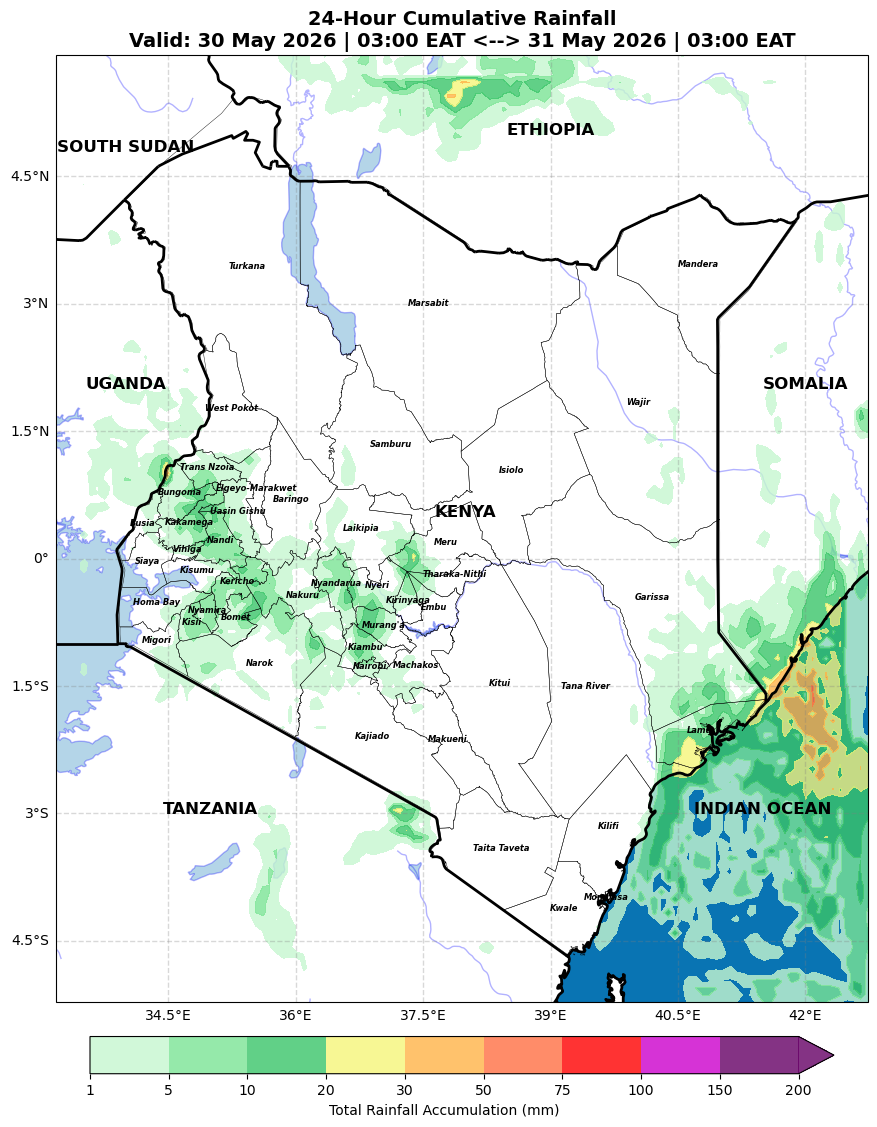

In [10]:
#  plot the variable 
fig = plt.figure(figsize=(12, 15))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

#  apply map features 
ax.add_feature(cfeature.OCEAN, facecolor="#0974b3", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
ax.add_feature(cfeature.LAKES, facecolor="#0974b3", edgecolor="blue", alpha=0.3, zorder=1)
ax.add_feature(cfeature.RIVERS, facecolor="#0974b3", edgecolor="blue", alpha=0.3, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=2, zorder=4)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=2, zorder=4)

#  plot rainfall on top of the basemape with some transparency so map features remain visibl
rain_end = getvar(ncfile, "RAINC", timeidx=-1) + getvar(ncfile, "RAINNC", timeidx=-1)
rain_total = rain_end - rain_start_var
    
contour = ax.contourf(
    to_np(lons), to_np(lats), to_np(rain_total),
    levels=levels, cmap=cmap, norm=norm, extend="max",
    transform=ccrs.PlateCarree(), zorder=2, alpha=0.8
)

#  apply the counties in the shapefile and their names 
counties.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=5)

for idx, row in counties.iterrows():
    ax.text(
        row.geometry.centroid.x, 
        row.geometry.centroid.y, 
        row['name'], 
        transform=ccrs.PlateCarree(), 
        fontsize=6, 
        fontstyle='italic',
        fontweight='bold', 
        ha='center',
        zorder=4
    )

#  label the neigbours of kenya
style = {
      'transform': ccrs.PlateCarree(), 
      'fontsize': 12, 
      'fontweight': 'bold', 
      'ha': 'center', 
      'zorder': 7
    }

ax.text(38.0, 0.5, "KENYA", **style)
ax.text(42.0, 2.0, "SOMALIA", **style)
ax.text(39.0, 5.0, "ETHIOPIA", **style)
ax.text(34.0, 2.0, "UGANDA", **style)
ax.text(35.0, -3.0, "TANZANIA", **style)
ax.text(34.0, 4.8, "SOUTH SUDAN", **style)
ax.text(41.5, -3.0, "INDIAN OCEAN", **style)

#  plot the glidlines and the labels for the latitudes and longitudes
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                            color='grey', alpha=0.3, linestyle='--')
        
gl.top_labels = gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'fontsize': 10, 'color': 'black'}
gl.ylabel_style = {'fontsize': 10, 'color': 'black'}


    
plt.colorbar(
    contour, ax=ax, orientation="horizontal", 
    pad=0.03, shrink=0.8, 
    label="Total Rainfall Accumulation (mm)",
    extend='max'
)
    
start_time_eat = format_eat_time(getvar(ncfile, "Times", timeidx=0).values)
end_time_eat = format_eat_time(getvar(ncfile, "Times", timeidx=-1).values)
    
plt.title(
    f"24-Hour Cumulative Rainfall\nValid: {start_time_eat} <--> {end_time_eat}",
    fontsize=14, fontweight="bold"
)

plt.show()

In [9]:
import os
import argparse
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar, latlon_coords, to_np
import pandas as pd
from datetime import timedelta

def run_filtered_rainfall(wrf_path, output_dir, selected_counties=None):
    # --- 1. SETUP & DATA ---
    ncfile = Dataset(wrf_path)
    all_counties = gpd.read_file("/home/erickwambugu/WEATHER/WORKFLOW/map_shapefile_kenya/ke_shp/ke.shp")
    
    # Filter counties based on your list
    if selected_counties:
        # Ensure the names match your 'counties' print output (case-sensitive)
        counties = all_counties[all_counties['name'].isin(selected_counties)]
    else:
        counties = all_counties

    # Dynamic Extent: Zoom to selected counties with a small buffer
    bounds = counties.total_bounds  # [minx, miny, maxx, maxy]
    lon_min, lat_min, lon_max, lat_max = bounds
    buffer = 0.2
    extent = [lon_min - buffer, lon_max + buffer, lat_min - buffer, lat_max + buffer]

    # --- 2. RAINFALL CALCULATION ---
    rain_start = getvar(ncfile, "RAINC", timeidx=0) + getvar(ncfile, "RAINNC", timeidx=0)
    rain_end = getvar(ncfile, "RAINC", timeidx=-1) + getvar(ncfile, "RAINNC", timeidx=-1)
    rain_total = rain_end - rain_start
    lats, lons = latlon_coords(rain_start)

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Map Styling
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1.5)
    
    # Plot only the filtered county boundaries
    counties.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=5)

    # Add labels for selected counties
    for _, row in counties.iterrows():
        ax.text(row.geometry.centroid.x, row.geometry.centroid.y, row['name'],
                transform=ccrs.PlateCarree(), fontsize=9, fontweight='bold', ha='center')

    # Rainfall Contours
    # set the colors for the plot and the levels for the scale 
    colors = [
        "#c6f7d0",  # very light green
        "#7be495",  # light green
        "#3ac569",  # green
        "#f5f57a",  # yellow
        "#ffb347",  # orange
        "#ff7043",  # dark orange
        "#ff0000",  # red
        "#cc00cc",  # purple
        "#660066",  # dark purple
    ]

    levels = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(levels, cmap.N)

    contour = ax.contourf(to_np(lons), to_np(lats), to_np(rain_total),
                          levels=levels, cmap=cmap, norm=norm, extend="max", 
                          transform=ccrs.PlateCarree(), zorder=2, alpha=0.7)
    
    plt.colorbar(contour, ax=ax, orientation="horizontal", pad=0.05, shrink=0.6, label="Rainfall (mm)")

    # Dynamic Title
    county_str = ", ".join(selected_counties) if selected_counties else "National"
    plt.title(f"Cumulative Rainfall Analysis\nArea: {county_str}", fontsize=14, fontweight="bold")

    plt.savefig(os.path.join(output_dir, "custom_county_rainfall.png"), dpi=300, bbox_inches="tight")
    plt.close()

if __name__ == "__main__":
    # --- YOUR CUSTOM LIST ---
    my_list = [] # Example: Central Region
    
    run_filtered_rainfall(
        wrf_path="/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00",
        output_dir=".",
        selected_counties=my_list
    )